# Разведочный анализ данных (EDA)

**Задача:** для каждого поискового запроса отобрать до 50 объявлений из корпуса Авито Услуг
(189 212 объявлений) так, чтобы в них попали объявления, которые пользователь в итоге выбрал.
Метрика — Recall@50.

Цели анализа:
1. понять, **как устроен бенчмарк**, чтобы построить валидацию, которая честно предсказывает результат на платформе;
2. найти **сигналы**, по которым можно отбирать кандидатов, и типичные причины ошибок.

Каждый раздел заканчивается выводом «→ что это значит для решения».

In [1]:
import sys, re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 80)

# Оформление графиков: светлая поверхность, приглушённые оси/сетка, один цвет ряда
SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d0",
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
                     "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

def hbar(labels, values, title, fmt="{:.0%}", xlabel=""):
    fig, ax = plt.subplots(figsize=(8, 0.55 * len(labels) + 1.2))
    y = np.arange(len(labels))[::-1]
    ax.barh(y, values, height=0.6, color=BLUE)
    for yi, v in zip(y, values):
        ax.text(v, yi, "  " + fmt.format(v), va="center", color=INK, fontsize=10)
    ax.set_yticks(y, labels); ax.set_title(title, loc="left", color=INK, fontsize=12)
    ax.set_xlim(0, max(values) * 1.18); ax.set_xlabel(xlabel); ax.grid(axis="y", visible=False)
    if fmt.endswith("%}"):
        from matplotlib.ticker import PercentFormatter
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    plt.tight_layout(); plt.show()

train = pd.read_parquet(ROOT / "data/train.parquet")
items = pd.read_parquet(ROOT / "data/benchmark_items.parquet")
bq = pd.read_parquet(ROOT / "data/benchmark_queries.parquet")
norm = lambda s: " ".join(str(s).lower().replace("ё", "е").split())
for d in (train, bq):
    d["qn"] = d.search_query.map(norm); d["flt"] = d.search_infm_params_text.fillna("")
    d["qkey"] = d.qn + "|" + d.search_location_id.astype(str) + "|" + d.flt + "|" + d.search_category.astype(str)
print(f"train: {len(train):,} строк | корпус: {len(items):,} объявлений | бенчмарк: {len(bq):,} запросов")
train.head(3)[["search_query", "search_location_id", "search_infm_params_text", "item_title_raw", "item_location_id"]]

train: 497,673 строк | корпус: 189,212 объявлений | бенчмарк: 2,452 запросов


,search_query,search_location_id,search_infm_params_text,item_title_raw,item_location_id
0,скупка телевизоров,652430,,Скупка б/у техники,652430
1,автоподбор,640860,Рейтинг пользователя 4 звезды и выше,Автоподбор Разовый осмотр автомобиля,640860
2,баня на дровах,653240,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье","Баня на дровах ""Прованс"" на Цветочной",653240


## 1. Запросы и выборы

In [2]:
per_key = train.groupby("qkey").size()
print(f"уникальных текстов запросов: {train.qn.nunique():,}")
print(f"уникальных запросов (текст + локация + фильтры + категория): {len(per_key):,}")
print(f"выборов на запрос: медиана {per_key.median():.0f}, среднее {per_key.mean():.2f}, доля запросов с 1 выбором {(per_key == 1).mean():.1%}")
print(f"уникальных текстов в бенчмарке: {bq.search_query.nunique()} из {len(bq)} "
      f"(после нормализации регистра/ё: {bq.qn.nunique()}) — практически каждый текст один раз")

уникальных текстов запросов: 73,873
уникальных запросов (текст + локация + фильтры + категория): 354,304
выборов на запрос: медиана 1, среднее 1.40, доля запросов с 1 выбором 83.6%
уникальных текстов в бенчмарке: 2452 из 2452 (после нормализации регистра/ё: 2451) — практически каждый текст один раз


**→ Вывод.** Один и тот же текст ищут во многих городах, а у запроса обычно 1–2 выбранных объявления.
В бенчмарке каждый текст встречается один раз — валидацию нужно строить так же (один запрос на текст),
иначе частые запросы будут переоценены.

## 2. Локация — главный фильтр

In [3]:
def hav(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))
for d in (train, items):
    d["lat"] = d.item_latitude.astype(float); d["lon"] = d.item_longitude.astype(float)
# центр локации поиска = медиана координат выбранных из неё объявлений (работает и для «регионов»)
cent = train.groupby("search_location_id")[["lat", "lon"]].median()
t = train.join(cent.rename(columns={"lat": "clat", "lon": "clon"}), on="search_location_id")
t["dist"] = hav(t.clat, t.clon, t.lat, t.lon)
t["same"] = t.search_location_id == t.item_location_id
print(f"объявление из той же локации, что и поиск: {t.same.mean():.1%}")
print(f"медианное расстояние до объявления: та же локация {t[t.same].dist.median():.1f} км, другая {t[~t.same].dist.median():.1f} км")
own = items.item_location_id.value_counts()
reg = t.groupby("search_location_id").agg(n=("same", "size"), same=("same", "mean"))
reg["объявлений_в_локации"] = reg.index.map(own).fillna(0).astype(int)
print("\nКрупнейшие локации поиска без собственных объявлений («регионы»):")
reg[reg["объявлений_в_локации"] == 0].sort_values("n", ascending=False).head(3)

объявление из той же локации, что и поиск: 83.1%


медианное расстояние до объявления: та же локация 2.6 км, другая 16.3 км

Крупнейшие локации поиска без собственных объявлений («регионы»):


,n,same,объявлений_в_локации
search_location_id,,,
107620,12277,0.0,0
621540,6839,0.0,0
107621,6310,0.0,0


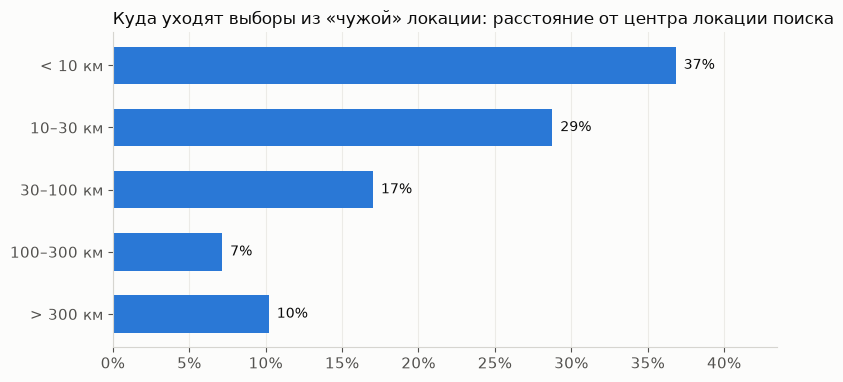

Из поиска в регионе 107620 выбирают объявления в локациях: {637640: 0.612, 638790: 0.028, 637770: 0.024}


In [4]:
mm = t.loc[~t.same, "dist"].dropna()
bins = [0, 10, 30, 100, 300, 1e9]; lab = ["< 10 км", "10–30 км", "30–100 км", "100–300 км", "> 300 км"]
share = pd.cut(mm, bins, labels=lab, right=False).value_counts(normalize=True).reindex(lab).to_numpy()
hbar(lab, share, "Куда уходят выборы из «чужой» локации: расстояние от центра локации поиска")
print("Из поиска в регионе 107620 выбирают объявления в локациях:",
      t[t.search_location_id == 107620].item_location_id.value_counts(normalize=True).head(3).round(3).to_dict())

In [5]:
# плотность корпуса: сколько объявлений бенчмарка лежит в локации каждого запроса
n_same = bq.search_location_id.map(items.item_location_id.value_counts()).fillna(0)
print(f"объявлений корпуса в локации запроса: медиана {n_same.median():.0f}, 90-й перцентиль {n_same.quantile(.9):.0f}, "
      f"у {(n_same == 0).mean():.0%} запросов своих объявлений нет (регионы)")

объявлений корпуса в локации запроса: медиана 1638, 90-й перцентиль 19543, у 17% запросов своих объявлений нет (регионы)


**→ Вывод.** 83% выборов — объявления той же локации, остальное — соседние города (десятки километров)
или поиск по «региону» (например, 107620 ≈ «Москва и область», своих объявлений у неё нет).
Поэтому вместо жёсткого фильтра используем **вероятность P(локация объявления | локация поиска)**,
выученную по истории, и расстояние до центра локации поиска. Внутри локации — сотни и тысячи
объявлений, так что основную работу делает текст.

## 3. Корпус и train — один срез данных

In [6]:
common = items.merge(train.drop_duplicates("item_id"), on="item_id", suffixes=("", "_tr"))
cols = ["item_title_raw", "item_price", "item_rating_reviews_count", "item_location_id", "item_infm_params_text"]
eq = {c: float(((common[c] == common[c + "_tr"]) | (common[c].isna() & common[c + "_tr"].isna())).mean()) for c in cols}
print(f"объявлений корпуса, встречающихся в train: {len(common):,} из {len(items):,} ({len(common)/len(items):.1%})")
print("совпадение признаков у общих объявлений:", {k: f"{v:.0%}" for k, v in eq.items()})
multi = train.groupby("item_id").qn.nunique()
print(f"строк train, где объявление выбирали и по другим текстам: {(train.item_id.map(multi) > 1).mean():.1%}")

объявлений корпуса, встречающихся в train: 18,142 из 189,212 (9.6%)
совпадение признаков у общих объявлений: {'item_title_raw': '100%', 'item_price': '100%', 'item_rating_reviews_count': '100%', 'item_location_id': '100%', 'item_infm_params_text': '100%'}


строк train, где объявление выбирали и по другим текстам: 40.1%


**→ Вывод.** Признаки объявлений в train и корпусе совпадают на 100% — это один срез, поэтому
объявления из train можно подмешивать в корпус при валидации без «временных» артефактов.
Треть–половина выборов приходится на объявления, которые выбирали и по другим запросам —
популярность объявления в истории станет признаком ранкера.

## 4. Как устроен бенчмарк — ключ к честной валидации

In [7]:
keys = train.drop_duplicates("qkey")[["qkey", "qn", "flt", "search_location_id"]]
n_keys_per_text = keys.groupby("qn").size()
A = keys.sample(20000, random_state=0)                                            # равномерно по событиям
B = keys.sample(frac=1, random_state=1).drop_duplicates("qn").sample(20000, random_state=2)   # по текстам
def stats(df, seen):
    return {"доля текстов, встречающихся в train": seen, "слов в запросе": df.qn.str.split().str.len().mean(),
            "доля с фильтром": (df.flt != "").mean(), "доля Москвы (637640)": (df.search_location_id == 637640).mean()}
tab = pd.DataFrame({
    "по событиям поиска": stats(A, (A.qn.map(n_keys_per_text) > 1).mean()),
    "по уникальным текстам": stats(B, (B.qn.map(n_keys_per_text) > 1).mean()),
    "бенчмарк": stats(bq, bq.qn.isin(set(train.qn)).mean())}).round(3)
tab

,по событиям поиска,по уникальным текстам,бенчмарк
"доля текстов, встречающихся в train",0.870,0.383,0.374
слов в запросе,2.452,3.100,3.197
доля с фильтром,0.648,0.525,0.369
доля Москвы (637640),0.056,0.112,0.134


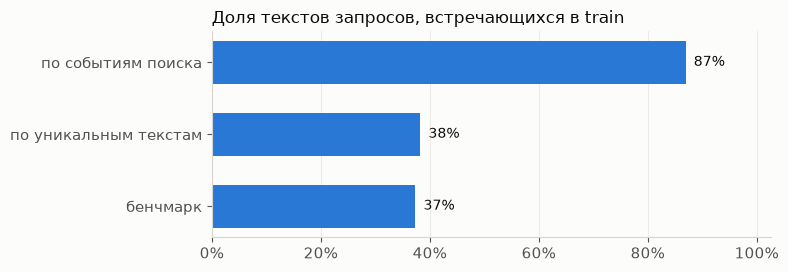

In [8]:
hbar(list(tab.columns), tab.iloc[0].to_numpy(), "Доля текстов запросов, встречающихся в train")

**→ Вывод.** Если бы бенчмарк был случайной выборкой событий поиска, ~87% его текстов встречались бы
в train. На деле — 37%, ровно как при выборке **равномерно по уникальным текстам** (38%); совпадают и
длина запросов, и перекос в сторону крупных городов. Значит, бенчмарк состоит в основном из редких
«хвостовых» формулировок.

Валидация построена так же: по одному запросу на текст, текст выбирается равномерно; 8 порций по 2 452
запроса; каждая ищет в корпусе «объявления бенчмарка + правильные ответы порции» (доля ответов в корпусе —
как в настоящем бенчмарке); все признаки из истории считаются по train **без** валидационных запросов.

## 5. Текст: насколько слова запроса есть в выбранном объявлении

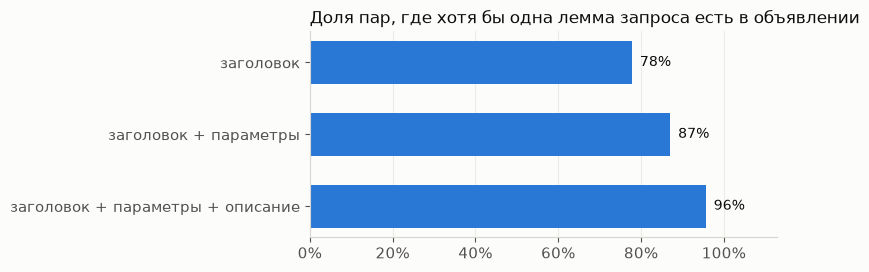

In [9]:
from src import text as T
s = train[train.qkey.isin(set(B.qkey))].sample(15000, random_state=0)
lem = lambda x, stop=False: set(T.lemmas(x, drop_stop=stop))
Q = s.qn.map(lambda x: lem(x, True))
ok = Q.map(len) > 0
s, Q = s[ok], Q[ok]
ti = s.item_title_raw.fillna("").map(lem); pa = s.item_infm_params_text.fillna("").map(lem); de = s.item_description_raw.fillna("").map(lem)
anyhit = lambda fields: np.mean([len(q & set().union(*f)) > 0 for q, *f in zip(Q, *fields)])
cov = {"заголовок": anyhit([ti]), "заголовок + параметры": anyhit([ti, pa]), "заголовок + параметры + описание": anyhit([ti, pa, de])}
hbar(list(cov), list(cov.values()), "Доля пар, где хотя бы одна лемма запроса есть в объявлении")

In [10]:
zero = [len(q & (a | b | c)) == 0 for q, a, b, c in zip(Q, ti, pa, de)]
s.loc[zero, ["search_query", "item_title_raw"]].sample(12, random_state=3)

,search_query,item_title_raw
61185,глажка белья тула,Сделаю сегодня
487148,дневной фейерверк,Шоколадный фонтан
134506,изготовление шлангов кондиционера,Заправка ремонт автокондиционеров и рефрижераторов
273976,исправление осанки,Инструктор ЛФК реабилитолог
235763,накладной хвост или каниколон прическа,"Брейды, косы"
396105,автостраховка,Каско миникаско с франшизой индивидуальные условия
355853,проводка воды в частный дом,"Монтаж отопления, тёплый пол"
401798,бетонанасос,"Бетон, Бетононасос, автобетононасос, миксер"
279356,перепашка огорода,Культивация земли мотоблоком
30462,дизинсекция,"Уничтожение тараканов, клопов, клещей, плесени"


**→ Вывод.** Описание обязательно индексировать (оно добавляет ~9 п.п. пар с совпадением), но с меньшим
весом, чем заголовок. У ~5% пар нет ни одного общего слова; типы таких ошибок и что с ними делаем:

| Тип | Пример | Инструмент |
|---|---|---|
| опечатки | «масажистка», «кортон» | символьные n-граммы заголовка |
| словообразование / слитное написание | «токарь» — «токарные», «грузтакси» | символьные n-граммы |
| синонимы и смысл | «разгрузка вагонов» — «бригада грузчиков» | дообученные эмбеддинги |
| запрос без слов из объявления | «бровки» — «мастер бровист» | классификатор «запрос → подкатегория» |

## 6. Фильтры поиска

In [11]:
from src.features.filters import parse_filter
stat = {}
sub = train[train.flt != ""].sample(150000, random_state=0)
for f, p in zip(sub.flt, sub.item_infm_params_text.fillna("")):
    for k, vs in parse_filter(f).items():
        n, m = stat.get(k, (0, 0)); stat[k] = (n + 1, m + any(f"{k} {v}" in p for v in vs))
pd.DataFrame({k: {"пар": n, "значение фильтра есть у объявления": m / n} for k, (n, m) in stat.items()}).T.sort_values("пар", ascending=False).round(3)

,пар,значение фильтра есть у объявления
Вид услуги,143976.0,0.984
Тип услуги,74129.0,0.979
Тип услуги автосервиса,12015.0,0.953
Аренда авто,1063.0,0.883
Чем вы занимаетесь,570.0,0.877
Предмет или специальность,557.0,0.856
Ваши клиенты,281.0,0.972
Где вы оказываете услуги,233.0,0.798
Специальность или сфера,134.0,0.716


In [12]:
print("запросов бенчмарка с фильтром «Автосервис»:", bq.flt.str.contains("Автосервис").sum(),
      "| в train это самый частый фильтр:", f"{train.flt.str.contains('Автосервис').mean():.1%} строк")

запросов бенчмарка с фильтром «Автосервис»: 0 | в train это самый частый фильтр: 12.4% строк


**→ Вывод.** «Вид услуги» и «Тип услуги» — почти жёсткие ограничения (98%): для запросов с фильтром
даём сильный бонус объявлениям, которые ему удовлетворяют (но не отсекаем остальные — 2% исключений).
Запросов с фильтром «Автосервис» в бенчмарке нет — исключаем их из валидации.

## 7. Подкатегории

In [13]:
g = train.groupby("qn").item_microcat_id.agg(lambda x: x.value_counts(normalize=True).iloc[0])
n = train.groupby("qn").size()
print(f"подкатегорий в train: {train.item_microcat_id.nunique()}; "
      f"доля выборов текста в его самой частой подкатегории (тексты с ≥5 выборами): {g[n >= 5].mean():.1%}")

подкатегорий в train: 212; доля выборов текста в его самой частой подкатегории (тексты с ≥5 выборами): 81.8%


**→ Вывод.** Текст запроса в среднем на ~80% «сидит» в одной подкатегории — классификатор
«текст → подкатегория» даёт сильный признак P(подкатегория объявления | запрос), который работает
и без общих слов.

## 8. Запросы «по всем категориям» (search_category = 0)

In [14]:
print(f"в бенчмарке: {(bq.search_category == 0).sum()} запросов ({(bq.search_category == 0).mean():.0%}); в train: {(train.search_category == 0).sum()} строк")
print(f"объявлений корпуса не из «Услуг»: {(items.item_category_id != 114).sum()}")
bq.loc[bq.search_category == 0, "search_query"].sample(12, random_state=0).tolist()

в бенчмарке: 222 запросов (9%); в train: 34 строк
объявлений корпуса не из «Услуг»: 1876


['курсы украшения',
 'обложка меню',
 'база',
 'специалист по настройкам окон пластиковых',
 'микроволновая печь ремонт',
 'вакансия репетитор онлайн математика информатика',
 '223 фз юрист',
 'творческая студия для подростков',
 'порошковая покраска высокая камера',
 'водитель с авто',
 'снять базу отдыха',
 'карта т-банк 1500']

**→ Вывод.** 9% запросов бенчмарка ищут по всем категориям, и часть из них — про товары/вакансии
(«брусчатка купить», «вакансия репетитор»). В train таких примеров почти нет, поэтому модель, обученная
на признаках рубрикатора Услуг, будет систематически занижать объявления других категорий. Для этих
запросов используем отдельную модель ранжирования без признаков подкатегории.

## Итог: решения, принятые по результатам EDA

| Наблюдение | Решение |
|---|---|
| бенчмарк = по одному запросу на уникальный текст | валидация с тем же сэмплингом, 8 порций по 2 452 запроса |
| 83% выборов в своей локации, остальное — соседи и регионы | P(локация объявления \| локация поиска) + расстояние, а не жёсткий фильтр |
| 95% пар имеют общие леммы (с описанием) | BM25F по заголовку, параметрам, описанию |
| опечатки, синонимы, «безсловные» запросы | n-граммы, дообученные эмбеддинги, классификатор подкатегорий |
| фильтры «Вид/Тип услуги» выполняются в 98% | бонус за выполненный фильтр при отборе + признаки |
| популярные объявления выбирают повторно | признаки популярности из истории |
| 9% запросов «по всем категориям» | отдельная модель без признаков рубрикатора |